In [39]:
# Calibrated parameters (slopes from your 2025 fit; base = representative circuit)
deg = {
    'SOFT':   {'base': 90.0, 'd': 0.0844},
    'MEDIUM': {'base': 90.6, 'd': 0.0369},
    'HARD':   {'base': 91.2, 'd': 0.0521},
}
FUEL = -0.10             # shared fuel effect (average of three fitted values)
PIT_LOSS = 26.4          # your measured green pit cost
N_LAPS   = 57            # race length
COMPOUNDS = ['SOFT', 'MEDIUM', 'HARD']

def lap_time(compound, tyre_age, lap_number):
    """Time for one lap: base + tyre wear + shared fuel effect."""
    p = deg[compound]
    return p['base'] + p['d'] * tyre_age + FUEL * lap_number

print("Fresh soft, lap 1:", round(lap_time('SOFT', 1, 1), 2))
print("Old soft, lap 20: ", round(lap_time('SOFT', 20, 20), 2))

Fresh soft, lap 1: 89.98
Old soft, lap 20:  89.69


In [40]:
def race_time(strategy):
    """
    strategy = list of stints, each (compound, n_laps).
    e.g. [('SOFT',18), ('MEDIUM',20), ('HARD',19)] = start soft, pit to medium
         on lap 19, pit to hard on lap 39. Must sum to N_LAPS.
    Returns total race time (seconds), or infinity if illegal.
    """
    # rule 1: stints must cover exactly the race
    if sum(n for _, n in strategy) != N_LAPS:
        return float('inf')
    # rule 2: must use at least two different compounds
    if len(set(c for c, _ in strategy)) < 2:
        return float('inf')

    total = 0.0
    lap = 1
    for i, (compound, n) in enumerate(strategy):
        # add a pit loss for every stint after the first
        if i > 0:
            total += PIT_LOSS
        # sum lap times over this stint
        for age in range(1, n + 1):
            total += lap_time(compound, age, lap)
            lap += 1
    return total

# test: a simple two-stop
test = [('SOFT', 18), ('MEDIUM', 20), ('HARD', 19)]
print("Test strategy total race time:", round(race_time(test), 1), "s")

Test strategy total race time: 5084.4 s


In [41]:
from itertools import product

def generate_strategies(n_laps, max_stops=2, min_stint=8):
    """
    All ways to split the race into stints with compound choices.
    max_stops = up to 2 pit stops (2 or 3 stints).
    min_stint = don't allow stints shorter than this (unrealistic).
    """
    strategies = []

    # 1-stop: two stints
    for L1 in range(min_stint, n_laps - min_stint + 1):
        L2 = n_laps - L1
        for c1, c2 in product(COMPOUNDS, repeat=2):
            strategies.append([(c1, L1), (c2, L2)])

    # 2-stop: three stints
    if max_stops >= 2:
        for L1 in range(min_stint, n_laps - 2*min_stint + 1):
            for L2 in range(min_stint, n_laps - L1 - min_stint + 1):
                L3 = n_laps - L1 - L2
                if L3 < min_stint:
                    continue
                for c1, c2, c3 in product(COMPOUNDS, repeat=3):
                    strategies.append([(c1, L1), (c2, L2), (c3, L3)])

    return strategies

all_strats = generate_strategies(N_LAPS)
print(f"Generated {len(all_strats)} candidate strategies")

Generated 16443 candidate strategies


In [42]:
def find_optimal(strategies):
    best, best_time = None, float('inf')
    for s in strategies:
        t = race_time(s)
        if t < best_time:
            best_time, best = t, s
    return best, best_time

best, best_time = find_optimal(all_strats)

print("OPTIMAL STRATEGY:")
lap = 1
for i, (comp, n) in enumerate(best):
    action = "START" if i == 0 else f"PIT on lap {lap-1} →"
    print(f"  {action:15s} {comp:6s} for {n} laps  (laps {lap}-{lap+n-1})")
    lap += n
print(f"\nTotal race time: {best_time:.1f}s  ({best_time/60:.2f} min)")
n_stops = len(best) - 1
print(f"Number of pit stops: {n_stops}")

OPTIMAL STRATEGY:
  START           SOFT   for 22 laps  (laps 1-22)
  PIT on lap 22 → MEDIUM for 35 laps  (laps 23-57)

Total race time: 5056.7s  (84.28 min)
Number of pit stops: 1


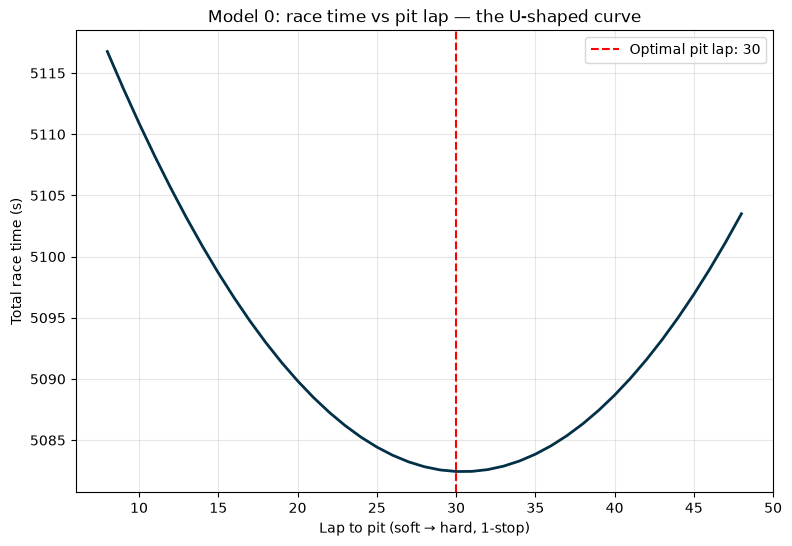

In [43]:
import matplotlib.pyplot as plt

# For a 1-stop soft→hard, sweep the pit lap and plot total time
pit_laps, times = [], []
for pit_on in range(8, N_LAPS - 8):
    s = [('SOFT', pit_on), ('HARD', N_LAPS - pit_on)]
    pit_laps.append(pit_on)
    times.append(race_time(s))

plt.figure(figsize=(9,6))
plt.plot(pit_laps, times, lw=2, color='#023047')
best_lap = pit_laps[times.index(min(times))]
plt.axvline(best_lap, color='red', ls='--', label=f'Optimal pit lap: {best_lap}')
plt.xlabel('Lap to pit (soft → hard, 1-stop)')
plt.ylabel('Total race time (s)')
plt.title('Model 0: race time vs pit lap — the U-shaped curve')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [44]:
# SANITY CHECK 1: higher pit cost -> fewer stops (and vice versa)
import copy

original_pit = PIT_LOSS
for test_pit in [5.0, 15.0, 26.4, 40.0]:
    PIT_LOSS = test_pit
    best_s, best_t = find_optimal(all_strats)
    stops = len(best_s) - 1
    print(f"Pit cost {test_pit:5.1f}s -> optimal has {stops} stop(s), time {best_t:.1f}s")
PIT_LOSS = original_pit   # restore!

# SANITY CHECK 2: equal wear rates -> roughly equal stints
print("\nWith all compounds forced to equal wear (d=0.05):")
saved = copy.deepcopy(deg)
for c in deg: deg[c]['d'] = 0.05
best_s, best_t = find_optimal(all_strats)
for comp, n in best_s: print(f"  {comp}: {n} laps")
deg = saved   # restore!

Pit cost   5.0s -> optimal has 2 stop(s), time 5024.5s
Pit cost  15.0s -> optimal has 2 stop(s), time 5044.5s
Pit cost  26.4s -> optimal has 1 stop(s), time 5056.7s
Pit cost  40.0s -> optimal has 1 stop(s), time 5070.3s

With all compounds forced to equal wear (d=0.05):
  MEDIUM: 22 laps
  SOFT: 35 laps


In [45]:
print(FUEL)                      # should print -0.1
print(deg['MEDIUM'])             # should have NO 'fuel' key — just base and d
print(lap_time('MEDIUM', 1, 50)) # should be 90.6 + 0.0369 - 5.0 = 85.64

-0.1
{'base': 90.6, 'd': 0.0369}
85.6369


In [46]:
import inspect
print(inspect.getsource(lap_time))

def lap_time(compound, tyre_age, lap_number):
    """Time for one lap: base + tyre wear + shared fuel effect."""
    p = deg[compound]
    return p['base'] + p['d'] * tyre_age + FUEL * lap_number

